In [1]:
import numpy as np
import pickle
import json
import os
from pathlib import Path
import torch
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.metrics import precision_recall_curve, roc_curve, auc

DATA_DIR = Path("/global/cfs/cdirs/m3246/gregork")
CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")

playlists = ["1A"]

training_names = { # Model -> training name
    "Transformer": "Pi_Class_v3_20260303_082729",
    "OmniLearned_Small": "Train_CC1orNPi_v3_1A_20260303_170126",
    "OmniLearned_Small_PT": "Train_CC1orNPi_v3_PT_S_1A_20260303_170241"
}


In [2]:
def eval_commands(training_names):
    for key in training_names.keys():
        for _ in playlists:
            if "omni" in key.lower():
                print(f"omnilearned evaluate -i {CKPT_DIR}/{training_names[key]} --num-workers 2 --batch 100")
            else:
                print(f"python -m src.scripts.eval --checkpoint {CKPT_DIR}/{training_names[key]} --batch_size 1024 --dataset_name minerva_1A --no_amp ")

eval_commands(training_names)


python -m src.scripts.eval --checkpoint /global/cfs/cdirs/m3246/gregork/checkpoints/Pi_Class_v3_20260303_082729 --batch_size 1024 --dataset_name minerva_1A --no_amp 
omnilearned evaluate -i /global/cfs/cdirs/m3246/gregork/checkpoints/Train_CC1orNPi_v3_1A_20260303_170126 --num-workers 2 --batch 100
omnilearned evaluate -i /global/cfs/cdirs/m3246/gregork/checkpoints/Train_CC1orNPi_v3_PT_S_1A_20260303_170241 --num-workers 2 --batch 100


In [3]:
results = {}
configs = {}
baselines = {}
for key in training_names.keys():
    results[key] = {}
    configs[key] = {}
    # File looks like this: $CKPT_DIR/training_name/outputs_cont_classification_current_type_<PLAYLIST>_20260204_013605_minerva_<PLAYLIST>_0.npz
    results[key] = {}
    configs[key] = {}
    for playlist in playlists:
        path1 = CKPT_DIR / training_names[key] / "test_results" / f"outputs_{training_names[key]}_minerva_{playlist}_0.npz"
        path2 = CKPT_DIR / training_names[key] / "test_results" / f"outputs_best_model_minerva_{playlist}_0.npz"
        if path1.exists():
            results[key][playlist] = dict(np.load(path1))
        elif path2.exists():
            results[key][playlist] = dict(np.load(path2))
        else:
            raise ValueError(f"No results found for {training_names[key]} on playlist {playlist} - {path1} and {path2} do not exist")
        settings_path = CKPT_DIR / training_names[key] / "settings.json"
        if settings_path.exists():
            configs[key][playlist] = json.load(open(settings_path, "rb"))
        else:
            print(f"No settings found for {training_names[key]} on playlist {playlist}")
            configs[key][playlist] = {}

# Softmax the transformer predictions
results["Transformer"]["1A"]["prediction"] = np.exp(results["Transformer"]["1A"]["prediction"]) / np.sum(np.exp(results["Transformer"]["1A"]["prediction"]), axis=1, keepdims=True)


No settings found for Pi_Class_v3_20260303_082729 on playlist 1A


In [4]:
data_paths = {}
for key in training_names.keys():
    data_paths[key] = {}
    data_paths[key] = {}
    for playlist in playlists:
        data_paths[key][playlist] = {}
        #models[key][model][playlist]["settings"] = configs[key][model][playlist]
        model_path = CKPT_DIR / training_names[key] / "best_model.pt"
        if os.path.exists(model_path):
            data_paths[key][playlist] = torch.load(model_path, weights_only=False, map_location=torch.device("cpu"))["args"]["data_path"]
        else:
            print(f"No best model found for {training_names[key]} on playlist {playlist}")
            del data_paths[key][playlist]

No best model found for Train_CC1orNPi_v3_1A_20260303_170126 on playlist 1A
No best model found for Train_CC1orNPi_v3_PT_S_1A_20260303_170241 on playlist 1A


In [5]:
default_data_dir = Path(data_paths["Transformer"][playlists[0]])
split_idx = pickle.load(open(default_data_dir / "result.pkl", "rb"))

baselines = {}
for playlist in playlists:
    test_idx = split_idx[playlist]["test_idx"]
    baseline_file = f"{playlist}_enu_baselines.npz"
    loaded = False
    for subdir in ["baselines2", "baselines1", "baselines"]:
        candidate = default_data_dir / subdir / baseline_file
        if candidate.exists():
            baselines[playlist] = dict(np.load(candidate))
            print(f"[{playlist}] Loaded baselines from {candidate}")
            loaded = True
            break
    if not loaded:
        print(f"[{playlist}] WARNING: No baselines found in {default_data_dir}")

[1A] Loaded baselines from /global/cfs/cdirs/m3246/gregork/Minerva/20260227_100Blobs_v1_split/baselines/1A_enu_baselines.npz


In [6]:
truth_labels = {}
default_model = "Transformer"
for key in data_paths[default_model].keys():
    truth_labels[key] = torch.load(open(Path(data_paths[default_model][key]) /  key / "test" / "0.pb", "rb"), weights_only=False, map_location=torch.device("cpu"))["truth_labels"]

In [7]:
def get_CC1orNPi_labels(file_truth_labels):
    # Generate labels for CC 1pi or n pions, according to signal definition in Eberly et al. 2015, on the fly
    is_cc = file_truth_labels[:, 3] == 1
    n_pi_plus = file_truth_labels[:, 5]
    n_pi_minus = file_truth_labels[:, 6]
    labels = torch.zeros(len(file_truth_labels), dtype=torch.long)
    one_pi_plus = n_pi_plus == 1
    one_pi_minus = n_pi_minus == 1
    multi_pions = (n_pi_plus + n_pi_minus) > 1
    labels[is_cc & one_pi_plus & ~one_pi_minus] = 0 # CC 1pi+
    labels[is_cc & one_pi_minus & ~one_pi_plus] = 1 # CC 1pi-
    labels[is_cc & multi_pions] = 2 # CC N Pi +-
    labels[~is_cc] = 3 # Not CC
    labels[is_cc & ((n_pi_plus + n_pi_minus) == 0)] = 4 # CC other
    return labels # Labels: 0=CC 1pi+, 1=CC 1pi-, 2=CC N charged pions-, 3=OTHER

def get_Pi_labels_v2(file_truth_labels):
    # label0 = CC, 1 charged pion, the rest whatever
    # label1 = CC, N >1charged pion, the rest whatever
    # label2 = CC, 1 pi0, no charged pions
    # label3 = CC, all others
    # label4 = NC
    is_cc = file_truth_labels[:, 3] == 1
    n_pi_plus = file_truth_labels[:, 5]
    n_pi_minus = file_truth_labels[:, 6]
    n_pi_zero = file_truth_labels[:, 10]
    labels = torch.ones(len(file_truth_labels), dtype=torch.long)*4 # 4 is the label for other
    labels[is_cc & (n_pi_plus == 1) & (n_pi_minus == 0)] = 0
    labels[is_cc & ((n_pi_plus + n_pi_minus) > 1)] = 1
    labels[is_cc & ((n_pi_plus + n_pi_minus) == 0)] = 3
    labels[is_cc & (n_pi_zero == 1) & (n_pi_plus == 0) & (n_pi_minus == 0)] = 2
    return labels
truth_labels_class = get_Pi_labels_v2(truth_labels["1A"])

In [8]:
class_labels, val_counts = torch.unique(truth_labels["1A"][:, 3], return_counts=True)
val_counts_relative = val_counts.numpy() / len(truth_labels["1A"]) * 100

In [9]:
class_idx, class_counts = torch.unique(truth_labels_class, return_counts=True) # print percentages
class_counts_all = class_counts.sum().item()
class_counts_percentages = class_counts.numpy() / class_counts_all * 100
print(f"Class fractions [%]: {class_counts_percentages}")
dataset_to_plot = "1A"

Class fractions [%]: [30.54664156 24.63314479  8.24744981 24.31750392 12.25525991]


In [10]:
# Get idx that have atleast one nonzero
idx = (truth_labels["1A"][:, -4:] != 0).any(axis=1)
truth_labels_class = get_CC1orNPi_labels(truth_labels["1A"][idx])

In [11]:
model_to_plot = "Transformer"
datasets = results[model_to_plot].keys()
labels_event_type = ["CC1pi+/-", "CCNpi", "CC1pi0", "Other-CC", "Other-NC"]

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix_on_ax(ax, y_true, y_pred, class_names):
    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    #ax.set_title("Confusion Matrix")
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)


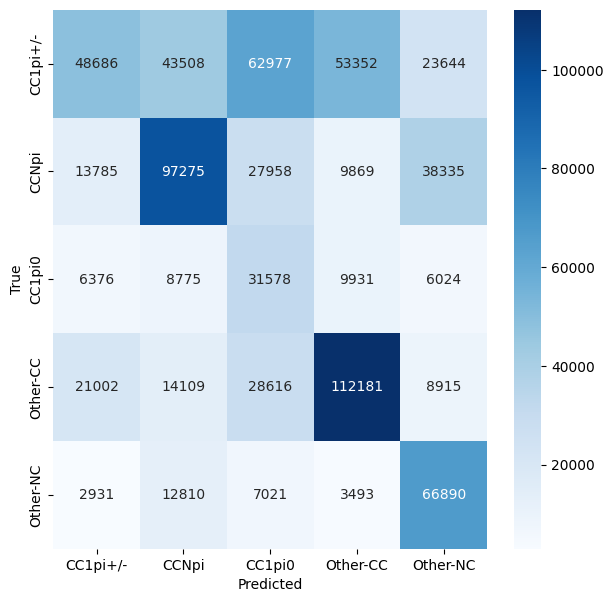

In [13]:
# 12 datasets: Make a 3 x 4 grid of confusion matrices
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
plot_confusion_matrix_on_ax(ax, results[model_to_plot][dataset_to_plot]["pid"], results[model_to_plot][dataset_to_plot]["prediction"].argmax(axis=1), labels_event_type)
fig.show()


In [14]:
def get_signal_probabilities(model_to_plot, dataset_to_plot="1A", signal_classes=None):
    remap = {}
    # set signal classes to 1 and the rest to 0.
    for cls in signal_classes:
        remap[cls] = 1
    y_true = np.array([remap.get(x, 0) for x in results[model_to_plot][dataset_to_plot]["pid"]])
    print("Fraction of signal:", y_true.mean())
    all_logits = results[model_to_plot][dataset_to_plot]["prediction"]
    all_probs = all_logits
    y_pred = sum([all_probs[:, i] for i in signal_classes])
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
    tpr, fpr, thresholds1 = roc_curve(y_true, y_pred)
    auprc = auc(recall, precision)
    auroc = auc(fpr, tpr)
    return {
        "prc": [precision, recall, thresholds, auprc],
        "roc": [tpr, fpr, thresholds1, auroc],
        "ytrue": y_true,
        "ypred": y_pred
    }

Fraction of signal: 0.305466415627578


Transformer: AUPRC: 0.471
Fraction of signal: 0.305466415627578
OmniLearned_Small: AUPRC: 0.472
Fraction of signal: 0.305466415627578
OmniLearned_Small_PT: AUPRC: 0.478


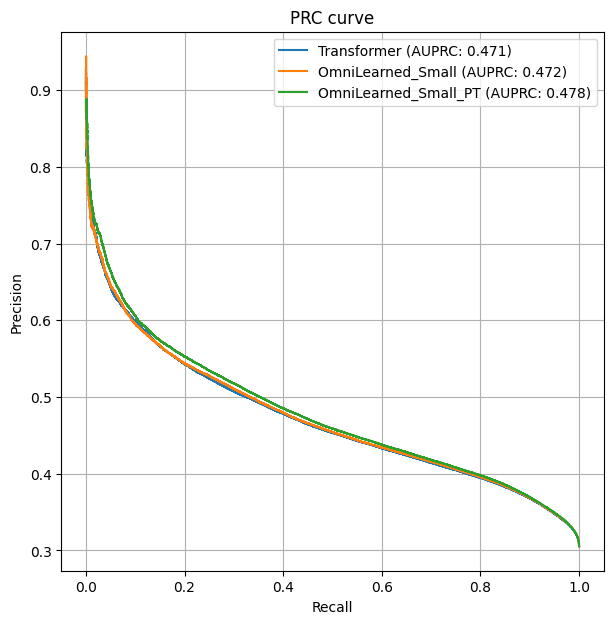

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
#fig_roc, ax_roc = plt.subplots(1, 1, figsize=(7, 7))

for model in results.keys():
    precision, recall, thresholds, auprc = get_signal_probabilities(model, "1A", [0])["prc"]
    # precision_recall_curve returns len(precision) == len(thresholds) + 1; drop sentinel
    precision = precision[:-1]
    recall = recall[:-1]
    # Remove thresholds < 0.01 and > 0.99
    mask = (thresholds >= 0) & (thresholds <= 0.8)
    precision = precision[mask]
    recall = recall[mask]
    thresholds = thresholds[mask]
    ax.plot(recall, precision, "-", label=model + f" (AUPRC: {auprc:.3f})")
    #ax_roc.plot(fpr, tpr, "-", label=model)
    # print auprc and auroc
    print(f"{model}: AUPRC: {auprc:.3f}")

ax.legend()
ax.grid()
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PRC curve")
fig.show()



In [16]:
test_idx = split_idx["1A"]["test_idx"]
pion_four_vector_MC = baselines["1A"]["pion_four_vectors"][test_idx] / 1000.0
pion_E_MC = pion_four_vector_MC[:, -1]
nonzero_mask = pion_E_MC > 0
pion_p_MC = np.linalg.norm(pion_four_vector_MC[:, 1:4], axis=1)
pion_theta_MC = np.arccos(pion_four_vector_MC[:, 2] / pion_p_MC)

/tmp/ipykernel_1385043/863099244.py:6: RuntimeWarning: invalid value encountered in divide
  pion_theta_MC = np.arccos(pion_four_vector_MC[:, 2] / pion_p_MC)


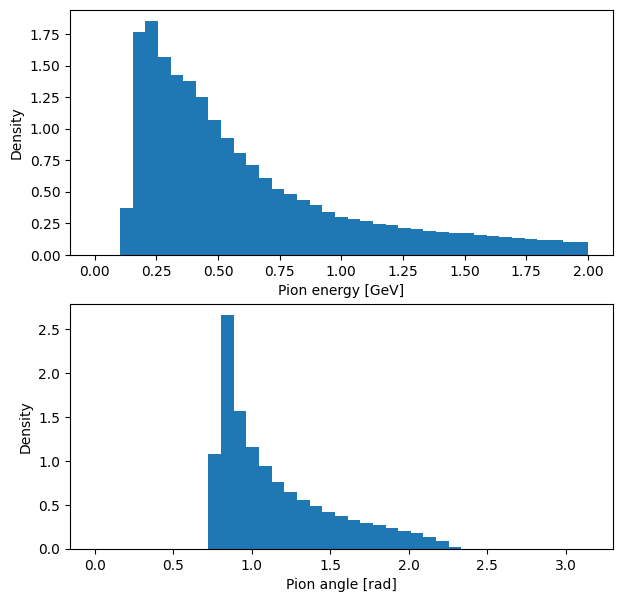

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(7, 7))
ax[0].hist(pion_E_MC[nonzero_mask], bins=np.linspace(0, 2, 40), density=True)
ax[1].hist(pion_theta_MC, bins=np.linspace(0, np.pi, 40), density=True)
ax[0].set_xlabel("Pion energy [GeV]")
ax[1].set_xlabel("Pion angle [rad]")
ax[0].set_ylabel("Density")
ax[1].set_ylabel("Density")
fig.show()


In [18]:

ytrue = results[model_to_plot][dataset_to_plot]["pid"]
mask1 = (ytrue == 0) | (ytrue == 2)
nonzero_pion_mask = (pion_four_vector_MC[:, -1] > 0)


In [19]:
N_BINS = 5
pion_E_MC_signal = pion_E_MC[nonzero_pion_mask & (pion_E_MC > 0)]
pion_theta_MC_signal = pion_theta_MC[nonzero_pion_mask & np.isfinite(pion_theta_MC)]
pion_E_MC_bins = np.quantile(pion_E_MC_signal, np.linspace(0, 1, N_BINS + 1))
pion_theta_MC_bins = np.quantile(pion_theta_MC_signal, np.linspace(0, 1, N_BINS + 1))
pion_E_MC_bins_mid = (pion_E_MC_bins[:-1] + pion_E_MC_bins[1:]) / 2
pion_theta_MC_bins_mid = (pion_theta_MC_bins[:-1] + pion_theta_MC_bins[1:]) / 2
print(f"E bins: {np.round(pion_E_MC_bins, 3)}")
print(f"theta bins: {np.round(pion_theta_MC_bins, 3)}")
threshold = 0.5
has_pion = nonzero_pion_mask


FIXED_FPR = [0.2]

def bin_separation_metrics(bin_mask, is_signal, is_background, y_true, probs, threshold):
    """Signal from `bin_mask` vs ALL background: AUPRC, AUROC, efficiency, purity, TPR@fixed FPR."""
    sig_in_bin = is_signal & bin_mask
    eval_mask = sig_in_bin | is_background
    y_eval = y_true[eval_mask]
    p_eval = probs[eval_mask]
    n_sig = sig_in_bin.sum()
    if n_sig == 0:
        return None
    prec, rec, _ = precision_recall_curve(y_eval, p_eval)
    auprc_val = auc(rec, prec)
    fpr_arr, tpr_arr, _ = roc_curve(y_eval, p_eval)
    auroc_val = auc(fpr_arr, tpr_arr)
    selected = p_eval > threshold
    tp = (selected & (y_eval == 1)).sum()
    tpr_at_fpr = {}
    for target_fpr in FIXED_FPR:
        idx = np.searchsorted(fpr_arr, target_fpr, side="right") - 1
        idx = max(0, min(idx, len(tpr_arr) - 1))
        tpr_at_fpr[target_fpr] = float(tpr_arr[idx])
    return {
        "auprc": auprc_val, "auroc": auroc_val,
        "efficiency": tp / n_sig if n_sig > 0 else 0.0,
        "purity": tp / selected.sum() if selected.sum() > 0 else 0.0,
        "n_signal": int(n_sig),
        "tpr_at_fpr": tpr_at_fpr,
    }


def compute_binned_metrics(model_name, dataset="1A", signal_classes=None, threshold=0.5):
    """Compute per-bin separation metrics for a model. Returns (metrics_E, metrics_theta)."""
    if signal_classes is None:
        signal_classes = [0]
    result = get_signal_probabilities(model_name, dataset, signal_classes)
    y_true = result["ytrue"]
    probs = result["ypred"]
    is_signal = (y_true == 1)
    is_background = (y_true == 0)

    metrics_E, metrics_theta = [], []
    for i in range(len(pion_E_MC_bins) - 1):
        lo, hi = pion_E_MC_bins[i], pion_E_MC_bins[i + 1]
        bin_mask = has_pion & (pion_E_MC > lo) & (pion_E_MC <= hi)
        metrics_E.append(bin_separation_metrics(bin_mask, is_signal, is_background, y_true, probs, threshold))

    for i in range(len(pion_theta_MC_bins) - 1):
        lo, hi = pion_theta_MC_bins[i], pion_theta_MC_bins[i + 1]
        bin_mask = has_pion & (pion_theta_MC > lo) & (pion_theta_MC <= hi)
        metrics_theta.append(bin_separation_metrics(bin_mask, is_signal, is_background, y_true, probs, threshold))

    return metrics_E, metrics_theta, is_signal, is_background


all_metrics = {}
for model_name in results.keys():
    mE, mT, is_sig, is_bg = compute_binned_metrics(model_name, threshold=threshold)
    all_metrics[model_name] = {"E": mE, "theta": mT, "is_signal": is_sig, "is_background": is_bg}
    print(f"\n{model_name}:  signal={is_sig.sum()}, background={is_bg.sum()}")
    for i, m in enumerate(mE):
        lo, hi = pion_E_MC_bins[i], pion_E_MC_bins[i + 1]
        if m:
            print(f"  E ({lo:.2f}, {hi:.2f}] GeV  N_sig={m['n_signal']:>6d}  "
                  f"AUPRC={m['auprc']:.3f}  AUROC={m['auroc']:.3f}  "
                  f"eff={m['efficiency']:.3f}  purity={m['purity']:.3f}")


E bins: [ 0.135  0.266  0.42   0.649  1.222 44.678]
theta bins: [0.785 0.841 0.946 1.131 1.463 2.332]
Fraction of signal: 0.305466415627578

Transformer:  signal=232167, background=527874
  E (0.14, 0.27] GeV  N_sig= 46319  AUPRC=0.177  AUROC=0.693  eff=0.062  purity=0.345
  E (0.27, 0.42] GeV  N_sig= 47136  AUPRC=0.212  AUROC=0.728  eff=0.078  purity=0.403
  E (0.42, 0.65] GeV  N_sig= 47141  AUPRC=0.172  AUROC=0.717  eff=0.041  purity=0.264
  E (0.65, 1.22] GeV  N_sig= 46237  AUPRC=0.147  AUROC=0.697  eff=0.025  purity=0.174
  E (1.22, 44.68] GeV  N_sig= 45334  AUPRC=0.100  AUROC=0.598  eff=0.014  purity=0.102
Fraction of signal: 0.305466415627578

OmniLearned_Small:  signal=232167, background=527874
  E (0.14, 0.27] GeV  N_sig= 46319  AUPRC=0.176  AUROC=0.694  eff=0.049  purity=0.360
  E (0.27, 0.42] GeV  N_sig= 47136  AUPRC=0.205  AUROC=0.728  eff=0.059  purity=0.410
  E (0.42, 0.65] GeV  N_sig= 47141  AUPRC=0.170  AUROC=0.717  eff=0.030  purity=0.264
  E (0.65, 1.22] GeV  N_sig= 46

<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1385043/941802079.py:45: SyntaxWarning: invalid escape sequence '\p'
  fig.suptitle("$CC1\pi\pm$ event tagging", fontsize=14)


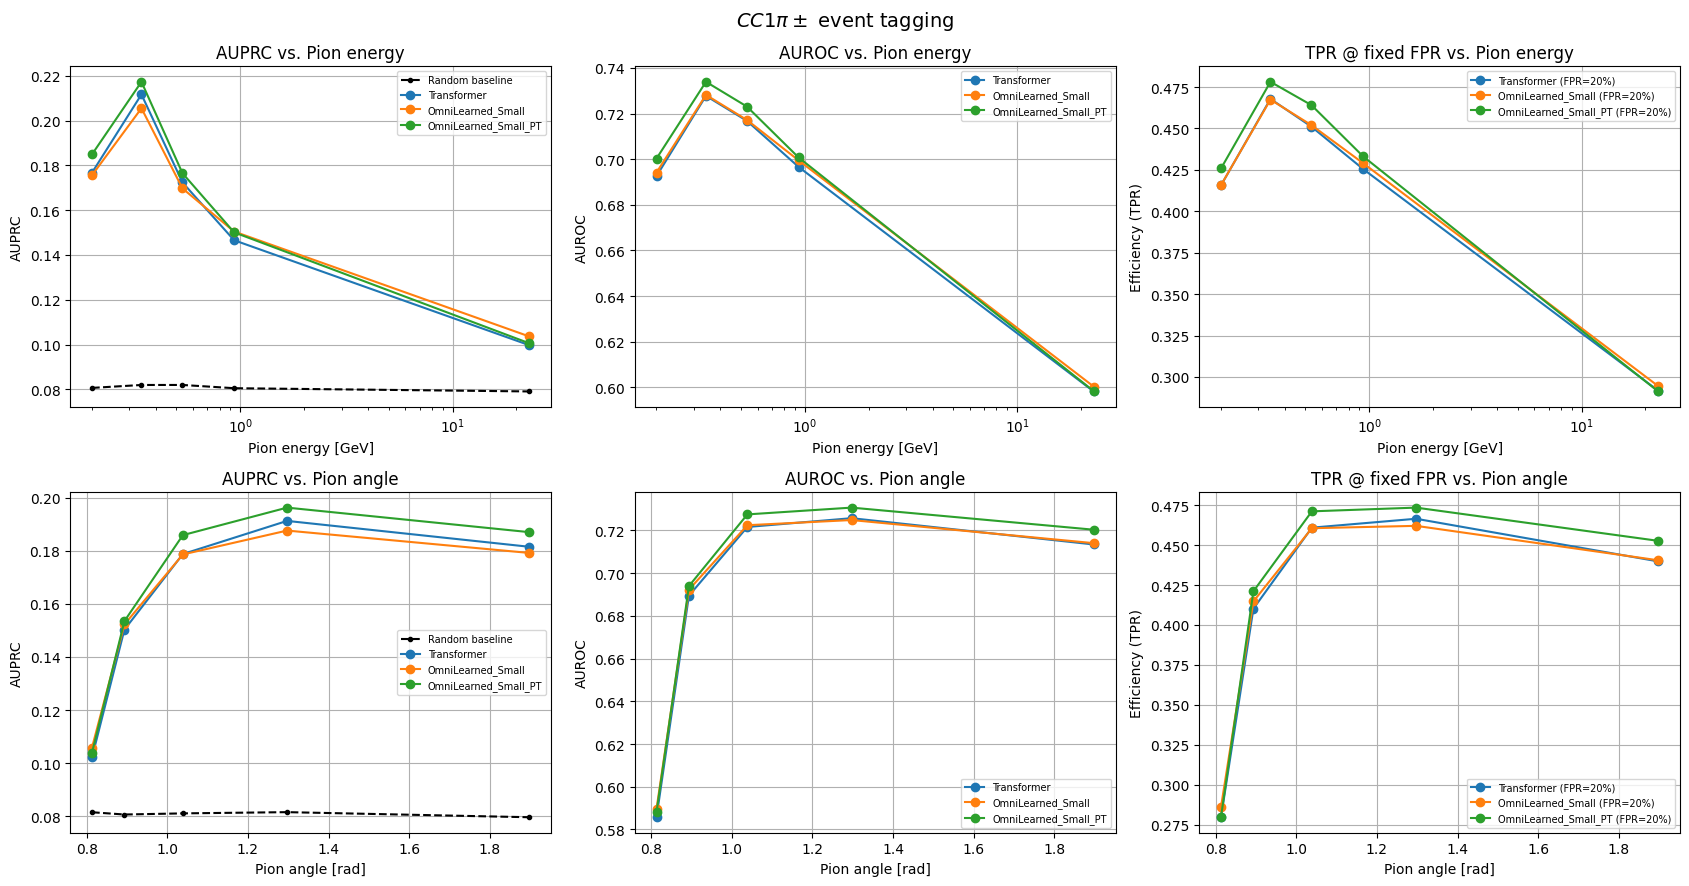

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9), tight_layout=True)

ref_model = next(iter(all_metrics))
ref = all_metrics[ref_model]
n_bg = ref["is_background"].sum()
baseline_E = [m["n_signal"] / (m["n_signal"] + n_bg) if m else np.nan for m in ref["E"]]
baseline_theta = [m["n_signal"] / (m["n_signal"] + n_bg) if m else np.nan for m in ref["theta"]]
axes[0, 0].plot(pion_E_MC_bins_mid, baseline_E, ".--", color="black", label="Signal fraction")
axes[1, 0].plot(pion_theta_MC_bins_mid, baseline_theta, ".--", color="black", label="Signal fraction")

for model_name, metrics in all_metrics.items():
    auprc_E = [m["auprc"] if m else np.nan for m in metrics["E"]]
    auprc_theta = [m["auprc"] if m else np.nan for m in metrics["theta"]]
    auroc_E = [m["auroc"] if m else np.nan for m in metrics["E"]]
    auroc_theta = [m["auroc"] if m else np.nan for m in metrics["theta"]]

    axes[0, 0].plot(pion_E_MC_bins_mid, auprc_E, "o-", label=model_name)
    axes[1, 0].plot(pion_theta_MC_bins_mid, auprc_theta, "o-", label=model_name)
    axes[0, 1].plot(pion_E_MC_bins_mid, auroc_E, "o-", label=model_name)
    axes[1, 1].plot(pion_theta_MC_bins_mid, auroc_theta, "o-", label=model_name)

    for target_fpr in FIXED_FPR:
        tpr_E = [m["tpr_at_fpr"][target_fpr] if m else np.nan for m in metrics["E"]]
        tpr_theta = [m["tpr_at_fpr"][target_fpr] if m else np.nan for m in metrics["theta"]]
        axes[0, 2].plot(pion_E_MC_bins_mid, tpr_E, "o-",
                        label=f"{model_name} (FPR={target_fpr:.0%})")
        axes[1, 2].plot(pion_theta_MC_bins_mid, tpr_theta, "o-",
                        label=f"{model_name} (FPR={target_fpr:.0%})")

col_labels = ["AUPRC", "AUROC", "Efficiency (TPR)"]
for row, kinematic in enumerate(["Pion energy [GeV]", "Pion angle [rad]"]):
    for col, metric in enumerate(col_labels):
        ax = axes[row, col]
        ax.set_xlabel(kinematic)
        ax.set_ylabel(metric)
        if col < 2:
            ax.set_title(f"{metric} vs. {kinematic.split('[')[0].strip()}")
        else:
            ax.set_title(f"TPR @ fixed FPR vs. {kinematic.split('[')[0].strip()}")
        ax.legend(fontsize=7)
        ax.grid(True)
        if row == 0:
            ax.set_xscale("log")
# set global title: 1 charged pion event tagging
fig.suptitle("$CC1\pi\pm$ event tagging", fontsize=14)
fig.show()

Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092


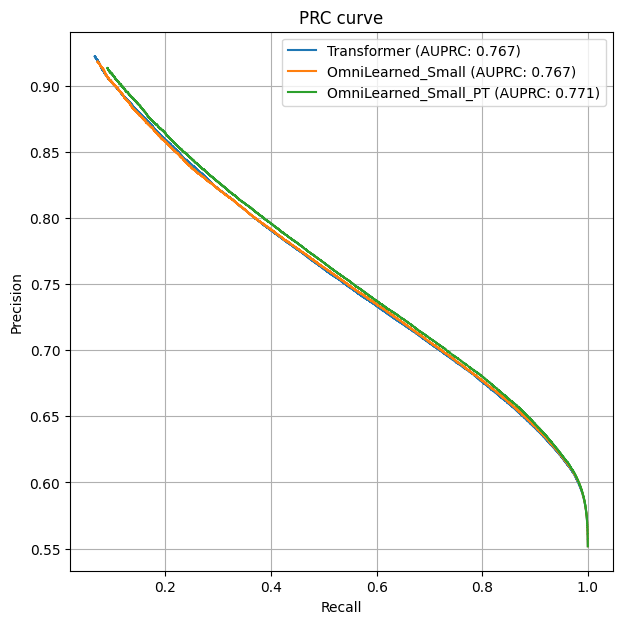

In [21]:
# Plot PRC curve for this too
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for model in results.keys():
    precision, recall, thresholds, auprc = get_signal_probabilities(model, "1A", [0, 1])["prc"]
    mask = (thresholds >= 0) & (thresholds <= 0.8)
    thresholds = thresholds[mask]
    precision = precision[:-1][mask]
    recall = recall[:-1][mask]
    ax.plot(recall, precision, "-", label=model + f" (AUPRC: {auprc:.3f})")
ax.legend()
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PRC curve")
ax.grid()
fig.show()

Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092


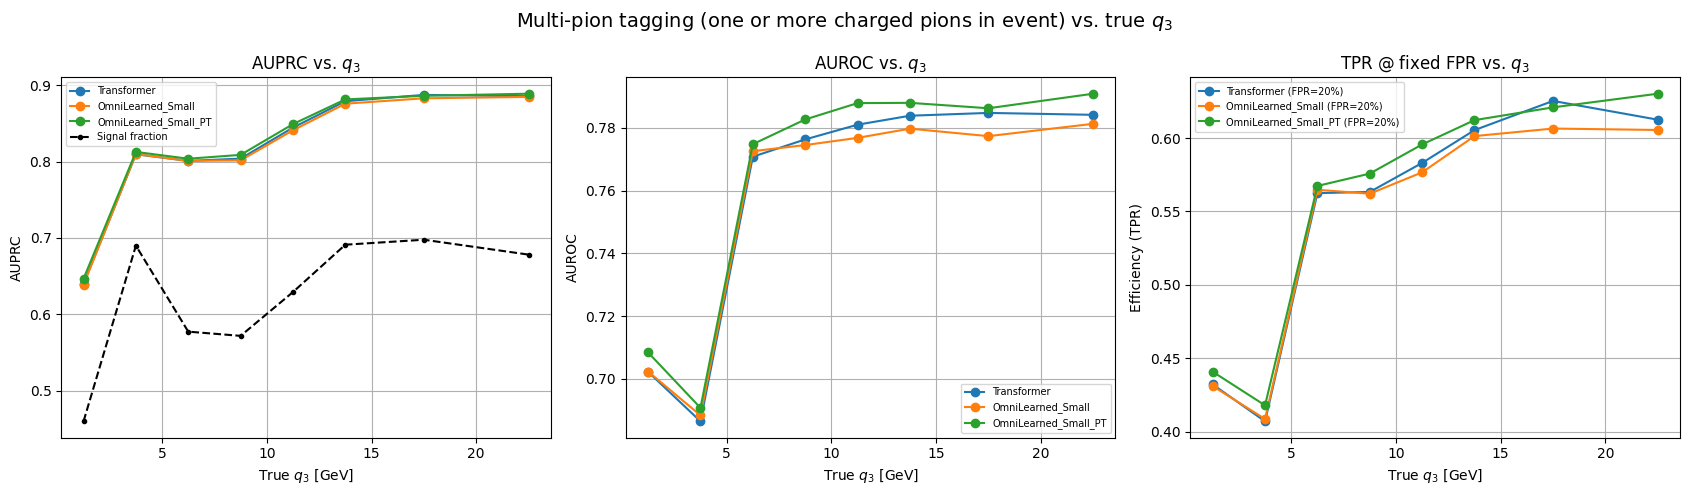

In [22]:
# AUPRC for multi-pion event tagging (classes [0, 1]) vs true q3

q3_GeV = baselines["1A"]["q3"][test_idx] / 1000.0

N_Q3_BINS = 5
q3_valid = q3_GeV[(q3_GeV > 0) & (q3_GeV < 40)]
#q3_bin_edges = np.quantile(q3_valid, np.linspace(0, 1, N_Q3_BINS + 1))
q3_bin_edges = np.array([0, 2.5, 5, 7.5, 10, 12.5, 15, 20, 25])
q3_bin_mids = (q3_bin_edges[:-1] + q3_bin_edges[1:]) / 2

signal_classes_multi_pi = [0, 1]

# Compute signal fraction per q3 bin (model-independent, use first model's labels)

first_model = list(results.keys())[0]
_sig_result = get_signal_probabilities(first_model, "1A", signal_classes_multi_pi)
_y_true = _sig_result["ytrue"]
sig_frac_per_bin = []

for i in range(len(q3_bin_edges) - 1):
    lo, hi = q3_bin_edges[i], q3_bin_edges[i + 1]
    bin_mask = (q3_GeV > lo) & (q3_GeV <= hi)
    n_in_bin = bin_mask.sum()
    sig_frac_per_bin.append(_y_true[bin_mask].mean() if n_in_bin > 0 else np.nan)

FIXED_FPR_Q3 = [0.2]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), tight_layout=True)

for model_name in results.keys():
    sig_result = get_signal_probabilities(model_name, "1A", signal_classes_multi_pi)
    y_true_q3 = sig_result["ytrue"]
    probs_q3 = sig_result["ypred"]

    auprc_per_bin = []
    auroc_per_bin = []
    tpr_at_fpr_per_bin = {fpr: [] for fpr in FIXED_FPR_Q3}

    for i in range(len(q3_bin_edges) - 1):
        lo, hi = q3_bin_edges[i], q3_bin_edges[i + 1]
        bin_mask = (q3_GeV > lo) & (q3_GeV <= hi)
        y_bin = y_true_q3[bin_mask]
        p_bin = probs_q3[bin_mask]
        n_sig = (y_bin == 1).sum()
        n_bg = (y_bin == 0).sum()
        if n_sig == 0 or n_bg == 0:
            auprc_per_bin.append(np.nan)
            auroc_per_bin.append(np.nan)
            for fpr in FIXED_FPR_Q3:
                tpr_at_fpr_per_bin[fpr].append(np.nan)
        else:
            prec, rec, _ = precision_recall_curve(y_bin, p_bin)
            auprc_per_bin.append(auc(rec, prec))
            fpr_arr, tpr_arr, _ = roc_curve(y_bin, p_bin)
            auroc_per_bin.append(auc(fpr_arr, tpr_arr))
            for target_fpr in FIXED_FPR_Q3:
                idx = np.searchsorted(fpr_arr, target_fpr, side="right") - 1
                idx = max(0, min(idx, len(tpr_arr) - 1))
                tpr_at_fpr_per_bin[target_fpr].append(float(tpr_arr[idx]))

    axes[0].plot(q3_bin_mids, auprc_per_bin, "o-", label=model_name)
    axes[1].plot(q3_bin_mids, auroc_per_bin, "o-", label=model_name)
    for target_fpr in FIXED_FPR_Q3:
        axes[2].plot(q3_bin_mids, tpr_at_fpr_per_bin[target_fpr], "o-",
                     label=f"{model_name} (FPR={target_fpr:.0%})")

axes[0].plot(q3_bin_mids, sig_frac_per_bin, ".--", color="black", label="Signal fraction")


col_labels = ["AUPRC", "AUROC", "Efficiency (TPR)"]
for col, metric in enumerate(col_labels):
    ax = axes[col]
    ax.set_xlabel("True $q_3$ [GeV]")
    ax.set_ylabel(metric)
    if col < 2:
        ax.set_title(f"{metric} vs. $q_3$")
    else:
        ax.set_title(f"TPR @ fixed FPR vs. $q_3$")
    ax.legend(fontsize=7)
    ax.grid(True)

fig.suptitle("Multi-pion tagging (one or more charged pions in event) vs. true $q_3$", fontsize=14)
fig.show()


In [23]:
"""Pi_Class_v3_20260304_145825
Pi_Class_v3_20260304_145633
Pi_Class_v3_20260303_082729
Train_CC1orNPi_v3_PT_M_1A_20260304_104018
Train_CC1orNPi_v3_1A_20260304_104020
Train_CC1orNPi_v3_PT_S_1A_20260304_104016
Train_CC1orNPi_v3_1A_20260304_104006
Train_CC1orNPi_v3_PT_M_1A_20260304_104006
Train_CC1orNPi_v3_PT_S_1A_20260304_104006
Train_CC1orNPi_v3_PT_S_1A_20260303_170241
"""

'Pi_Class_v3_20260304_145825\nPi_Class_v3_20260304_145633\nPi_Class_v3_20260303_082729\nTrain_CC1orNPi_v3_PT_M_1A_20260304_104018\nTrain_CC1orNPi_v3_1A_20260304_104020\nTrain_CC1orNPi_v3_PT_S_1A_20260304_104016\nTrain_CC1orNPi_v3_1A_20260304_104006\nTrain_CC1orNPi_v3_PT_M_1A_20260304_104006\nTrain_CC1orNPi_v3_PT_S_1A_20260304_104006\nTrain_CC1orNPi_v3_PT_S_1A_20260303_170241\n'

In [28]:
mc_intType = {
    1: "QE",
    2: "RES",
    3: "DIS",
    4: "COH",
    8: "MEC/2p2h"
}

#

Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092
Fraction of signal: 0.5517978635363092


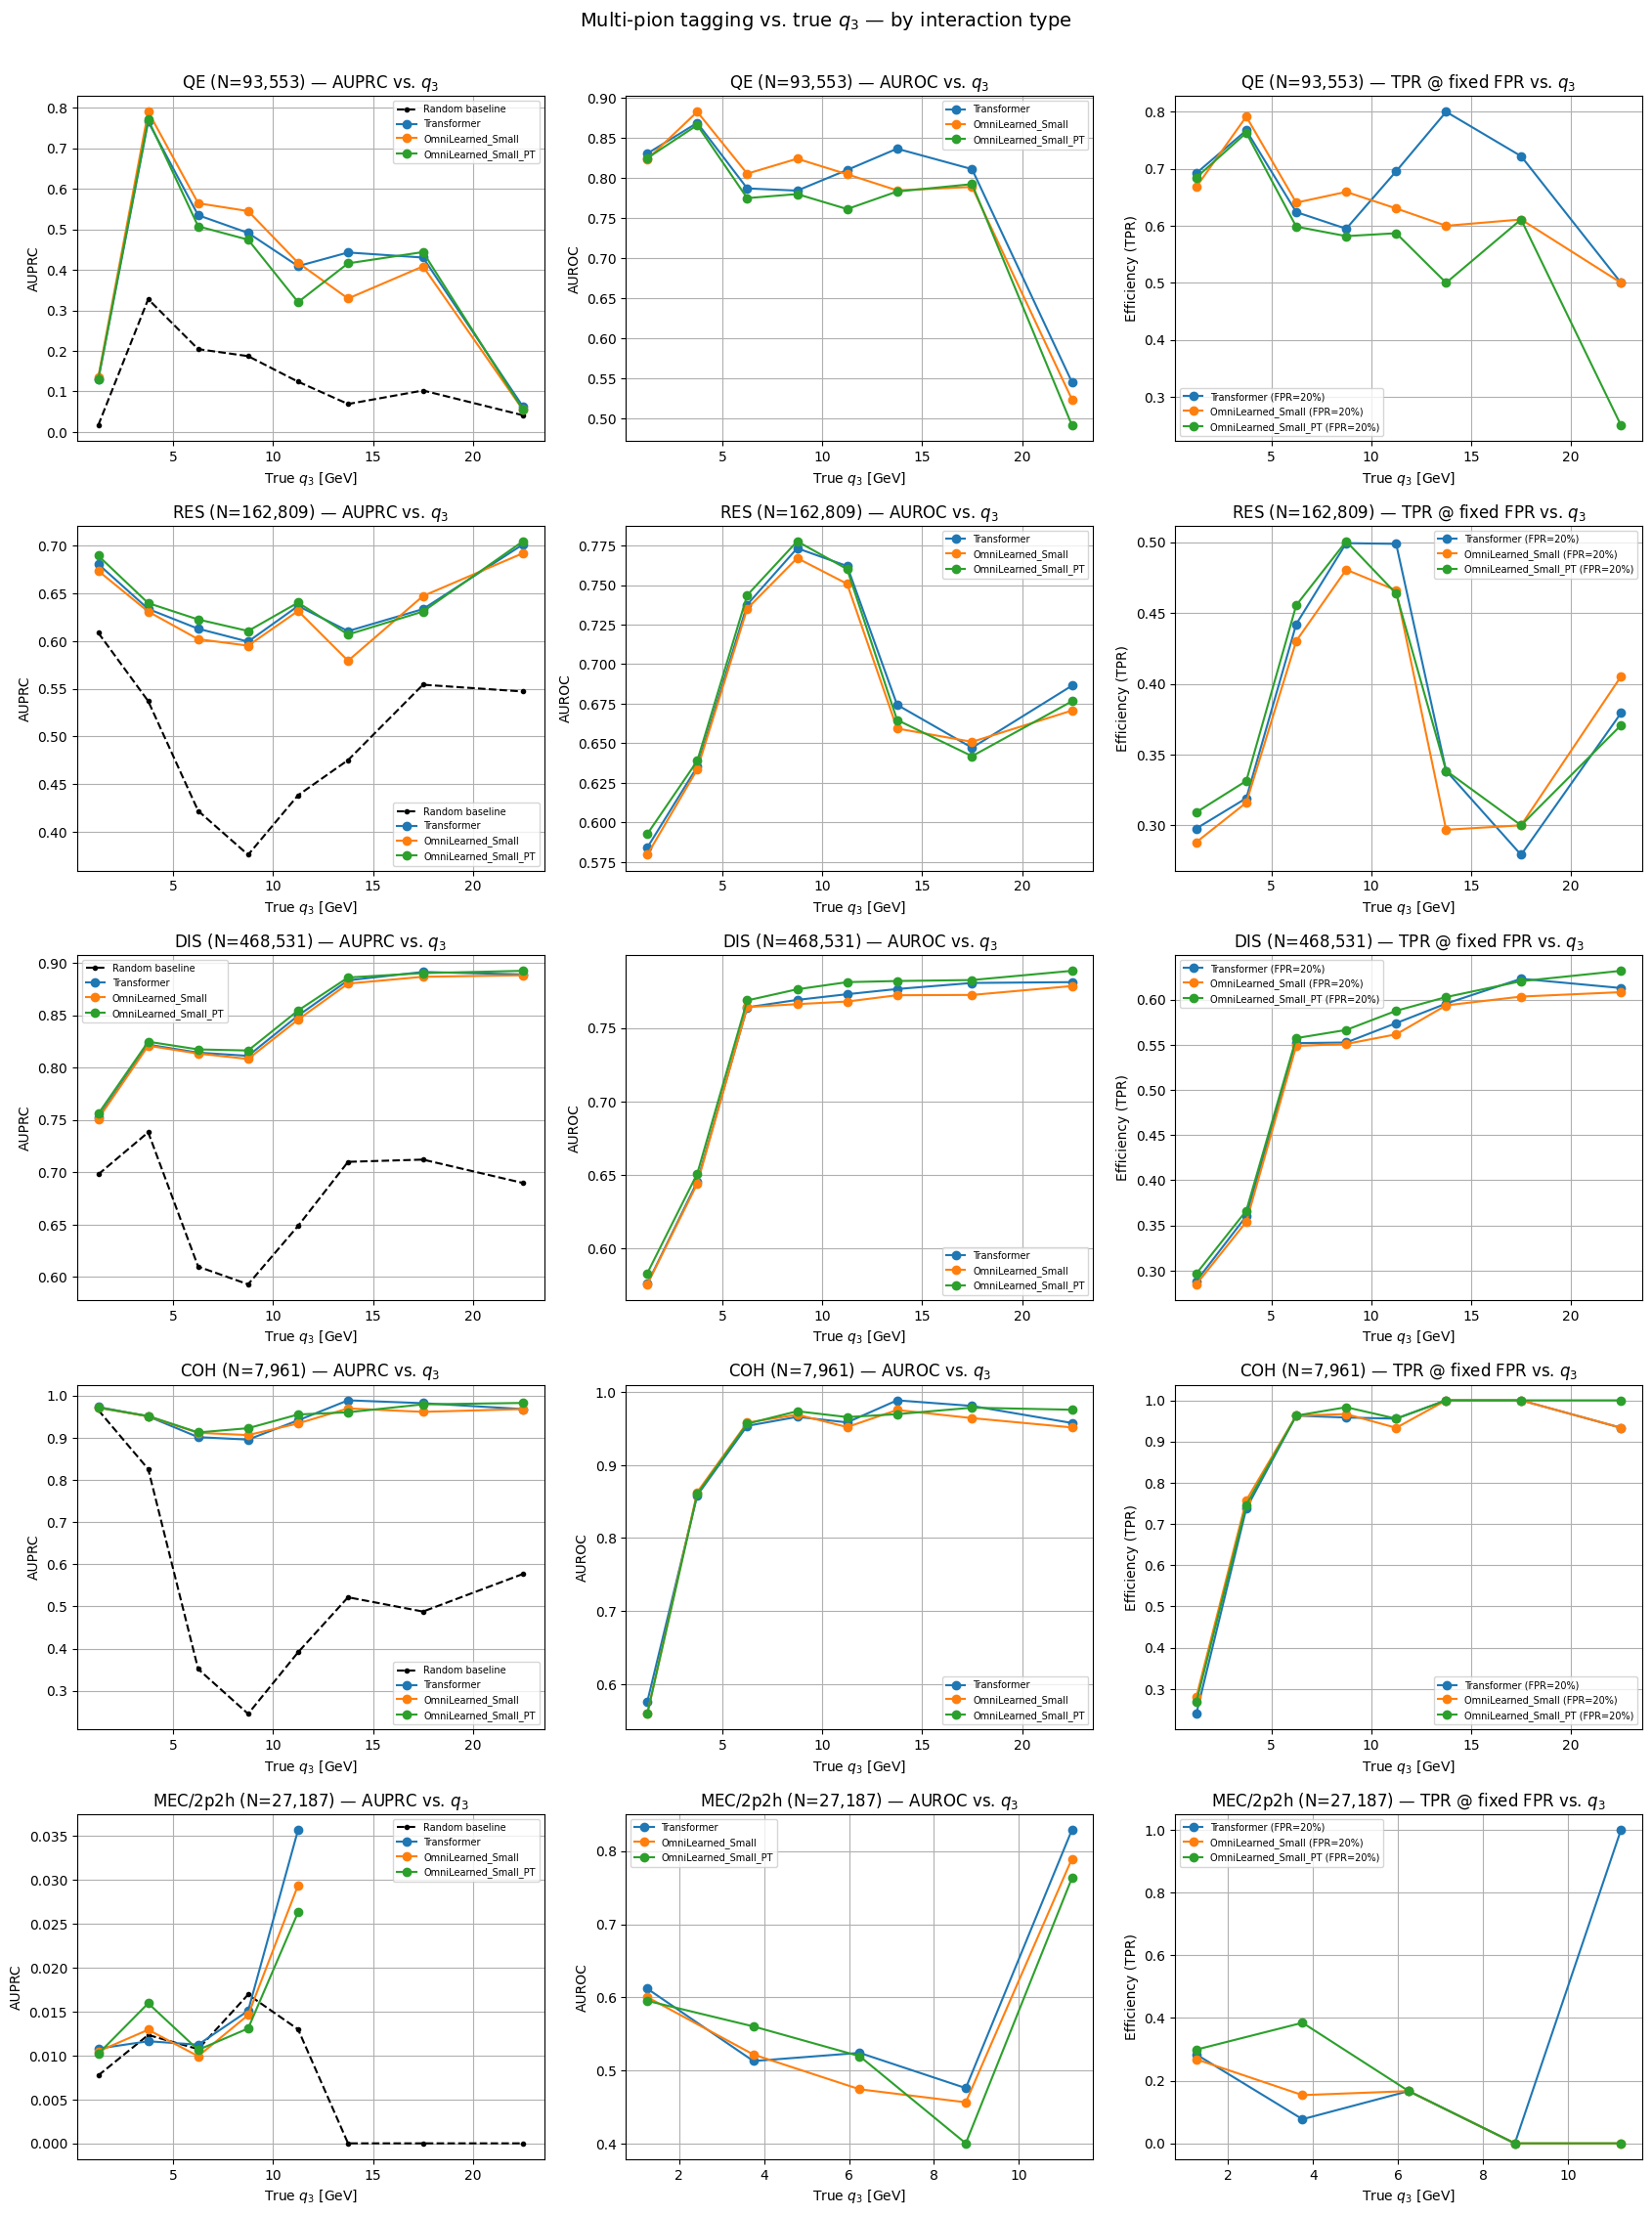

In [29]:
int_type_arr = truth_labels["1A"][:, 1].numpy()

n_int_types = len(mc_intType)
fig, axes = plt.subplots(n_int_types, 3, figsize=(17, 4.5 * n_int_types), tight_layout=True)

for row_idx, (int_code, int_name) in enumerate(mc_intType.items()):
    int_mask = (int_type_arr == int_code)
    n_events_int = int_mask.sum()

    # Random baseline: signal fraction per q3 bin for this interaction type
    sig_frac_int = []
    for i in range(len(q3_bin_edges) - 1):
        lo, hi = q3_bin_edges[i], q3_bin_edges[i + 1]
        bin_mask = (q3_GeV > lo) & (q3_GeV <= hi) & int_mask
        n_in_bin = bin_mask.sum()
        sig_frac_int.append(_y_true[bin_mask].mean() if n_in_bin > 0 else np.nan)
    axes[row_idx, 0].plot(q3_bin_mids, sig_frac_int, ".--", color="black", label="Random baseline")

    for model_name in results.keys():
        sig_result = get_signal_probabilities(model_name, "1A", signal_classes_multi_pi)
        y_true_q3 = sig_result["ytrue"]
        probs_q3 = sig_result["ypred"]

        auprc_per_bin, auroc_per_bin = [], []
        tpr_at_fpr_per_bin = {fpr: [] for fpr in FIXED_FPR_Q3}

        for i in range(len(q3_bin_edges) - 1):
            lo, hi = q3_bin_edges[i], q3_bin_edges[i + 1]
            bin_mask = (q3_GeV > lo) & (q3_GeV <= hi) & int_mask
            y_bin = y_true_q3[bin_mask]
            p_bin = probs_q3[bin_mask]
            n_sig = (y_bin == 1).sum()
            n_bg = (y_bin == 0).sum()
            if n_sig == 0 or n_bg == 0:
                auprc_per_bin.append(np.nan)
                auroc_per_bin.append(np.nan)
                for fpr in FIXED_FPR_Q3:
                    tpr_at_fpr_per_bin[fpr].append(np.nan)
            else:
                prec, rec, _ = precision_recall_curve(y_bin, p_bin)
                auprc_per_bin.append(auc(rec, prec))
                fpr_arr, tpr_arr, _ = roc_curve(y_bin, p_bin)
                auroc_per_bin.append(auc(fpr_arr, tpr_arr))
                for target_fpr in FIXED_FPR_Q3:
                    idx = np.searchsorted(fpr_arr, target_fpr, side="right") - 1
                    idx = max(0, min(idx, len(tpr_arr) - 1))
                    tpr_at_fpr_per_bin[target_fpr].append(float(tpr_arr[idx]))

        axes[row_idx, 0].plot(q3_bin_mids, auprc_per_bin, "o-", label=model_name)
        axes[row_idx, 1].plot(q3_bin_mids, auroc_per_bin, "o-", label=model_name)
        for target_fpr in FIXED_FPR_Q3:
            axes[row_idx, 2].plot(q3_bin_mids, tpr_at_fpr_per_bin[target_fpr], "o-",
                                  label=f"{model_name} (FPR={target_fpr:.0%})")

    col_labels = ["AUPRC", "AUROC", "Efficiency (TPR)"]
    for col, metric in enumerate(col_labels):
        ax = axes[row_idx, col]
        ax.set_xlabel("True $q_3$ [GeV]")
        ax.set_ylabel(metric)
        if col < 2:
            ax.set_title(f"{int_name} (N={n_events_int:,}) — {metric} vs. $q_3$")
        else:
            ax.set_title(f"{int_name} (N={n_events_int:,}) — TPR @ fixed FPR vs. $q_3$")
        ax.legend(fontsize=7)
        ax.grid(True)

fig.suptitle("Multi-pion tagging vs. true $q_3$ — by interaction type", fontsize=14, y=1.005)
fig.show()

Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578


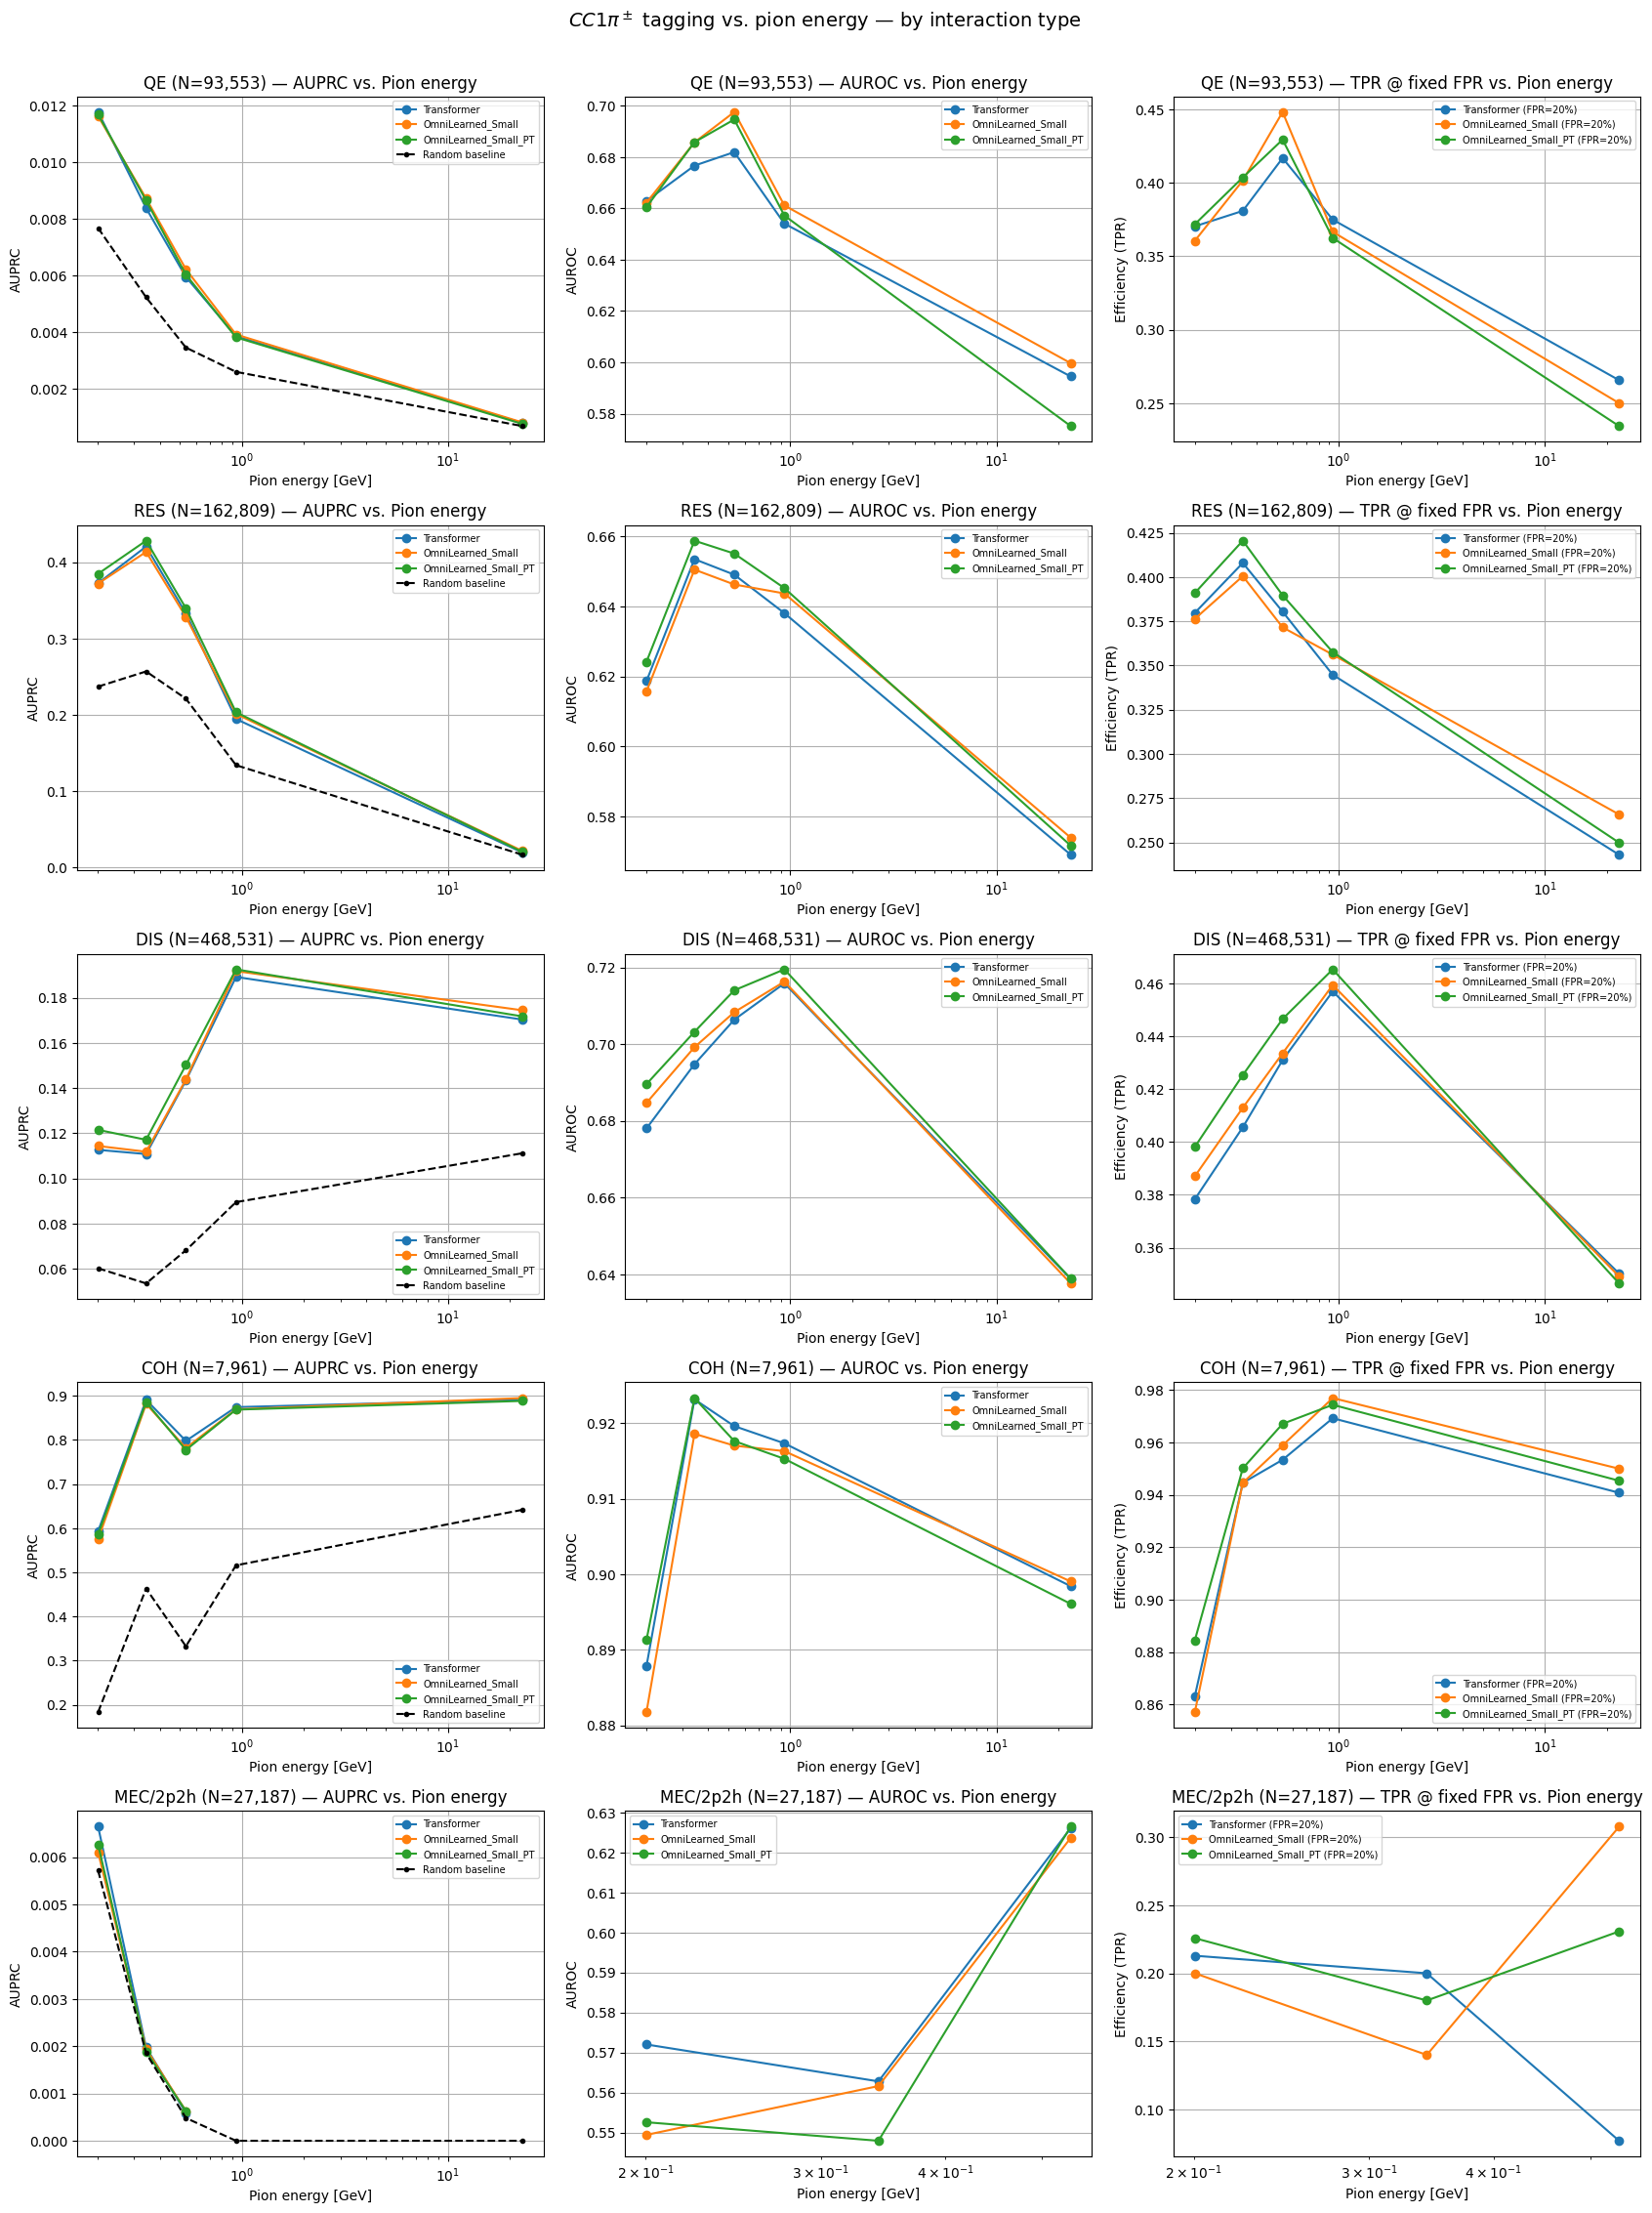

In [30]:
int_type_arr = truth_labels["1A"][:, 1].numpy()
cc1pi_signal_classes = [0]

n_int_types = len(mc_intType)
fig, axes = plt.subplots(n_int_types, 3, figsize=(17, 4.5 * n_int_types), tight_layout=True)

for row_idx, (int_code, int_name) in enumerate(mc_intType.items()):
    int_mask = (int_type_arr == int_code)
    n_events_int = int_mask.sum()

    # Random baseline per pion-E bin
    first_model = next(iter(results))
    ref_result = get_signal_probabilities(first_model, "1A", cc1pi_signal_classes)
    ref_y = ref_result["ytrue"]
    n_bg_int = ((ref_y == 0) & int_mask).sum()

    baseline_E, baseline_theta = [], []
    for i in range(len(pion_E_MC_bins) - 1):
        lo, hi = pion_E_MC_bins[i], pion_E_MC_bins[i + 1]
        bin_mask = has_pion & (pion_E_MC > lo) & (pion_E_MC <= hi) & int_mask
        n_sig_bin = ((ref_y == 1) & bin_mask).sum()
        baseline_E.append(n_sig_bin / (n_sig_bin + n_bg_int) if (n_sig_bin + n_bg_int) > 0 else np.nan)
    for i in range(len(pion_theta_MC_bins) - 1):
        lo, hi = pion_theta_MC_bins[i], pion_theta_MC_bins[i + 1]
        bin_mask = has_pion & (pion_theta_MC > lo) & (pion_theta_MC <= hi) & int_mask
        n_sig_bin = ((ref_y == 1) & bin_mask).sum()
        baseline_theta.append(n_sig_bin / (n_sig_bin + n_bg_int) if (n_sig_bin + n_bg_int) > 0 else np.nan)

    for model_name in results.keys():
        sig_result = get_signal_probabilities(model_name, "1A", cc1pi_signal_classes)
        y_true = sig_result["ytrue"]
        probs = sig_result["ypred"]
        is_signal = (y_true == 1)
        is_background = (y_true == 0)

        auprc_E, auroc_E, tpr_E_list = [], [], {fpr: [] for fpr in FIXED_FPR}
        auprc_theta, auroc_theta, tpr_theta_list = [], [], {fpr: [] for fpr in FIXED_FPR}

        for i in range(len(pion_E_MC_bins) - 1):
            lo, hi = pion_E_MC_bins[i], pion_E_MC_bins[i + 1]
            bin_mask = has_pion & (pion_E_MC > lo) & (pion_E_MC <= hi)
            m = bin_separation_metrics(bin_mask & int_mask, is_signal & int_mask, is_background & int_mask, y_true, probs, threshold)
            auprc_E.append(m["auprc"] if m else np.nan)
            auroc_E.append(m["auroc"] if m else np.nan)
            for fpr in FIXED_FPR:
                tpr_E_list[fpr].append(m["tpr_at_fpr"][fpr] if m else np.nan)

        for i in range(len(pion_theta_MC_bins) - 1):
            lo, hi = pion_theta_MC_bins[i], pion_theta_MC_bins[i + 1]
            bin_mask = has_pion & (pion_theta_MC > lo) & (pion_theta_MC <= hi)
            m = bin_separation_metrics(bin_mask & int_mask, is_signal & int_mask, is_background & int_mask, y_true, probs, threshold)
            auprc_theta.append(m["auprc"] if m else np.nan)
            auroc_theta.append(m["auroc"] if m else np.nan)
            for fpr in FIXED_FPR:
                tpr_theta_list[fpr].append(m["tpr_at_fpr"][fpr] if m else np.nan)

        axes[row_idx, 0].plot(pion_E_MC_bins_mid, auprc_E, "o-", label=model_name)
        axes[row_idx, 1].plot(pion_E_MC_bins_mid, auroc_E, "o-", label=model_name)
        for fpr in FIXED_FPR:
            axes[row_idx, 2].plot(pion_E_MC_bins_mid, tpr_E_list[fpr], "o-",
                                  label=f"{model_name} (FPR={fpr:.0%})")

    axes[row_idx, 0].plot(pion_E_MC_bins_mid, baseline_E, ".--", color="black", label="Random baseline")

    col_labels = ["AUPRC", "AUROC", "Efficiency (TPR)"]
    for col, metric in enumerate(col_labels):
        ax = axes[row_idx, col]
        ax.set_xlabel("Pion energy [GeV]")
        ax.set_ylabel(metric)
        if col < 2:
            ax.set_title(f"{int_name} (N={n_events_int:,}) — {metric} vs. Pion energy")
        else:
            ax.set_title(f"{int_name} (N={n_events_int:,}) — TPR @ fixed FPR vs. Pion energy")
        ax.legend(fontsize=7)
        ax.grid(True)
        ax.set_xscale("log")

fig.suptitle("$CC1\\pi^\\pm$ tagging vs. pion energy — by interaction type", fontsize=14, y=1.005)
fig.show()

Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578
Fraction of signal: 0.305466415627578


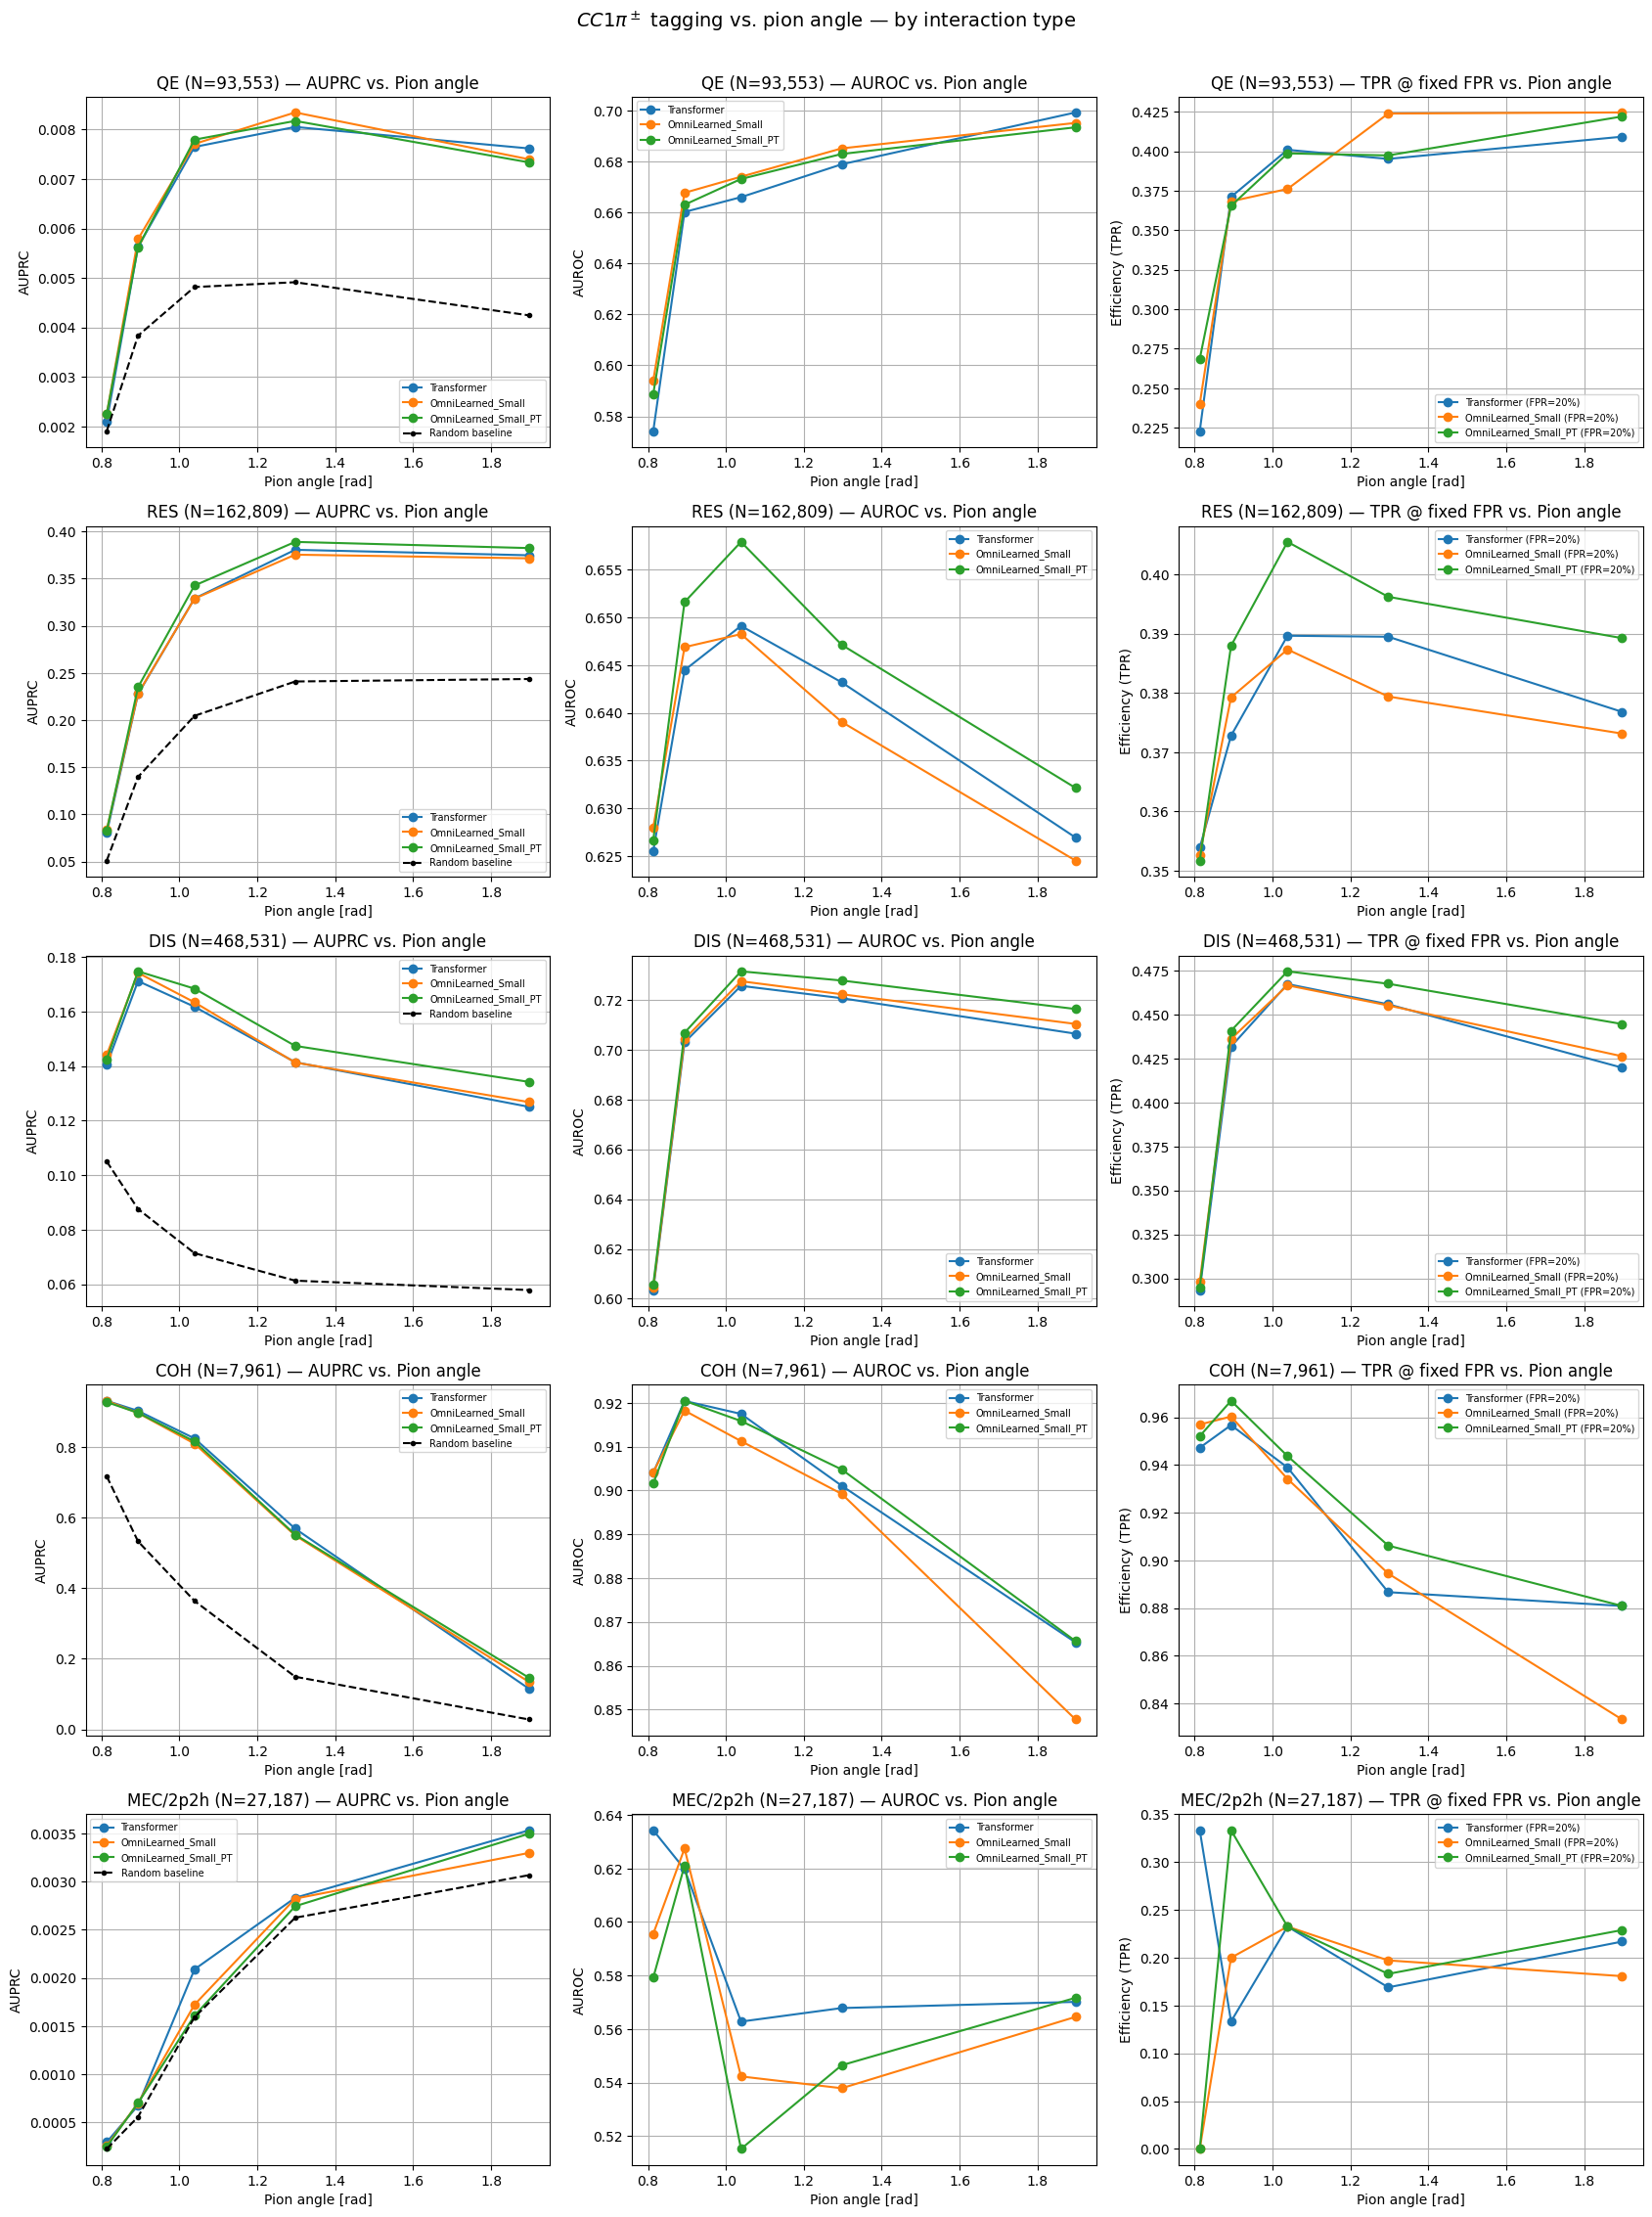

In [31]:
fig2, axes2 = plt.subplots(n_int_types, 3, figsize=(17, 4.5 * n_int_types), tight_layout=True)

for row_idx, (int_code, int_name) in enumerate(mc_intType.items()):
    int_mask = (int_type_arr == int_code)
    n_events_int = int_mask.sum()

    ref_result = get_signal_probabilities(first_model, "1A", cc1pi_signal_classes)
    ref_y = ref_result["ytrue"]
    n_bg_int = ((ref_y == 0) & int_mask).sum()

    baseline_theta = []
    for i in range(len(pion_theta_MC_bins) - 1):
        lo, hi = pion_theta_MC_bins[i], pion_theta_MC_bins[i + 1]
        bin_mask = has_pion & (pion_theta_MC > lo) & (pion_theta_MC <= hi) & int_mask
        n_sig_bin = ((ref_y == 1) & bin_mask).sum()
        baseline_theta.append(n_sig_bin / (n_sig_bin + n_bg_int) if (n_sig_bin + n_bg_int) > 0 else np.nan)

    for model_name in results.keys():
        sig_result = get_signal_probabilities(model_name, "1A", cc1pi_signal_classes)
        y_true = sig_result["ytrue"]
        probs = sig_result["ypred"]
        is_signal = (y_true == 1)
        is_background = (y_true == 0)

        auprc_theta, auroc_theta, tpr_theta_list = [], [], {fpr: [] for fpr in FIXED_FPR}

        for i in range(len(pion_theta_MC_bins) - 1):
            lo, hi = pion_theta_MC_bins[i], pion_theta_MC_bins[i + 1]
            bin_mask = has_pion & (pion_theta_MC > lo) & (pion_theta_MC <= hi)
            m = bin_separation_metrics(bin_mask & int_mask, is_signal & int_mask, is_background & int_mask, y_true, probs, threshold)
            auprc_theta.append(m["auprc"] if m else np.nan)
            auroc_theta.append(m["auroc"] if m else np.nan)
            for fpr in FIXED_FPR:
                tpr_theta_list[fpr].append(m["tpr_at_fpr"][fpr] if m else np.nan)

        axes2[row_idx, 0].plot(pion_theta_MC_bins_mid, auprc_theta, "o-", label=model_name)
        axes2[row_idx, 1].plot(pion_theta_MC_bins_mid, auroc_theta, "o-", label=model_name)
        for fpr in FIXED_FPR:
            axes2[row_idx, 2].plot(pion_theta_MC_bins_mid, tpr_theta_list[fpr], "o-",
                                   label=f"{model_name} (FPR={fpr:.0%})")

    axes2[row_idx, 0].plot(pion_theta_MC_bins_mid, baseline_theta, ".--", color="black", label="Random baseline")

    col_labels = ["AUPRC", "AUROC", "Efficiency (TPR)"]
    for col, metric in enumerate(col_labels):
        ax = axes2[row_idx, col]
        ax.set_xlabel("Pion angle [rad]")
        ax.set_ylabel(metric)
        if col < 2:
            ax.set_title(f"{int_name} (N={n_events_int:,}) — {metric} vs. Pion angle")
        else:
            ax.set_title(f"{int_name} (N={n_events_int:,}) — TPR @ fixed FPR vs. Pion angle")
        ax.legend(fontsize=7)
        ax.grid(True)

fig2.suptitle("$CC1\\pi^\\pm$ tagging vs. pion angle — by interaction type", fontsize=14, y=1.005)
fig2.show()